# Object Tracking and People Counting at a Store Entrance with Ultralytics YOLO

In retail, knowing how many people enter and leave your store is critical to measure performance. **Footfall data** helps estimate conversion rates, optimize staffing, and evaluate marketing campaigns. In this notebook, we use YOLO11 to detect and track customers in a store entrance video and build a simple in/out counter.

### Why People Counting Matters for Marketing

- **Footfall metrics**: Track visitors per hour/day to understand busy periods
- **Conversion rates**: Compare visitor counts with sales data to measure store effectiveness
- **Staffing optimization**: Align employee schedules with customer traffic patterns
- **Campaign evaluation**: Measure the impact of promotions on store visits
- **Occupancy management**: Monitor real-time store capacity for safety and comfort

> **Note:** We use Ultralytics YOLO11 for person detection and tracking, focusing specifically on the `person` class.

## Table of Contents

1. Setup and Imports
2. People Tracking vs People Detection
3. Tracking with Ultralytics YOLO
4. Track IDs and Common Challenges
5. Store Entrance Video Demo
6. Counting Customers with Entry/Exit Zones
7. Exercises: Footfall Analysis
8. Recap

## Setup and Imports

In [1]:
# Optional: install in fresh environments
# %pip install ultralytics opencv-python

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from collections import Counter

%matplotlib inline

# Fix for potential library conflicts on some systems
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

# Load YOLO11 model
model = YOLO("yolo11n.pt")
print(f"Model loaded: {model.model_name}")

Model loaded: yolo11n.pt


In [3]:
# Helper function for displaying frames
def show_frame(img, roi=None, window_name="YOLO Tracking"):
    """
    Display an image frame with optional ROI rectangle.
    Works in both Colab and local environments.
    """
    if roi is not None:
        x1, y1, x2, y2 = roi
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 3)
    
    try:
        # Colab environment
        from google.colab.patches import cv2_imshow
        from IPython.display import clear_output
        clear_output(wait=True)
        cv2_imshow(img)
    except ImportError:
        # Local environment
        cv2.imshow(window_name, img)

## People Tracking vs People Detection

**People detection** identifies and localizes individuals in a single image frame, outputting bounding boxes. Each frame is processed independently.

**People tracking** extends detection by maintaining consistent identifiers for each person across multiple frames. This allows us to follow individuals over time, which is essential for:

- **Counting customers** entering and leaving retail stores
- **Analyzing foot traffic patterns** in commercial spaces
- **Monitoring occupancy** for safety and comfort
- **Measuring conversion rates** when combined with sales data

### Tracking-by-Detection Paradigm

Modern tracking systems like Ultralytics YOLO use a **tracking-by-detection** approach:

1. A person detector runs on each frame independently
2. A tracking algorithm associates detections across consecutive frames
3. Each person receives a persistent ID that follows them through the video

This is different from classical single-object trackers that use correlation filters or template matching to follow one specific target, or optical flow methods that track pixel movements between frames.

### Challenges in People Tracking

- **Occlusion**: People may temporarily disappear behind others or objects
- **People entering/leaving**: New people appear, others exit the frame
- **ID switches**: The tracker may incorrectly swap IDs between similar-looking people
- **Missed detections**: People may not be detected in some frames
- **Appearance changes**: Lighting, angle, or pose changes can confuse the tracker
- **Crowding**: Dense crowds make it harder to maintain distinct IDs

## Tracking with Ultralytics YOLO

Ultralytics provides built-in tracking capabilities. Instead of `model(image)`, we use:

```python
results = model.track(frame, persist=True)
```

Key parameters:
- **`persist=True`**: Maintain track history across frames
- **`tracker="botsort.yaml"`**: Use BoT-SORT tracker (default)
- **`tracker="bytetrack.yaml"`**: Use ByteTrack tracker
- **`classes=[0]`**: Filter for person class only (class 0 in COCO)

### Tracking Algorithms in Ultralytics

Ultralytics supports several tracking algorithms that differ in how they associate detections across frames:

**SORT / DeepSORT**
- Uses Kalman filter to predict object positions and Hungarian algorithm for assignment
- Simple, fast, and works well when detections are stable
- DeepSORT adds appearance features (re-identification) for better association

**ByteTrack**
- Uses both high-confidence and low-confidence detections
- Low-score detections help maintain tracks during partial occlusions
- Particularly effective in crowded scenes with many overlapping people

**BoT-SORT** (default in Ultralytics)
- Combines motion prediction with appearance features
- More robust to occlusions and short-term disappearances
- Good balance between speed and accuracy for people tracking

Example with different trackers:

```python
# Default BoT-SORT
results = model.track(frame, persist=True, tracker="botsort.yaml", classes=[0])

# ByteTrack for dense crowds
results = model.track(frame, persist=True, tracker="bytetrack.yaml", classes=[0])
```

Let's start with a single frame from our store entrance video.

Using existing local video at ../data/store_entrance_people_going_in.mp4


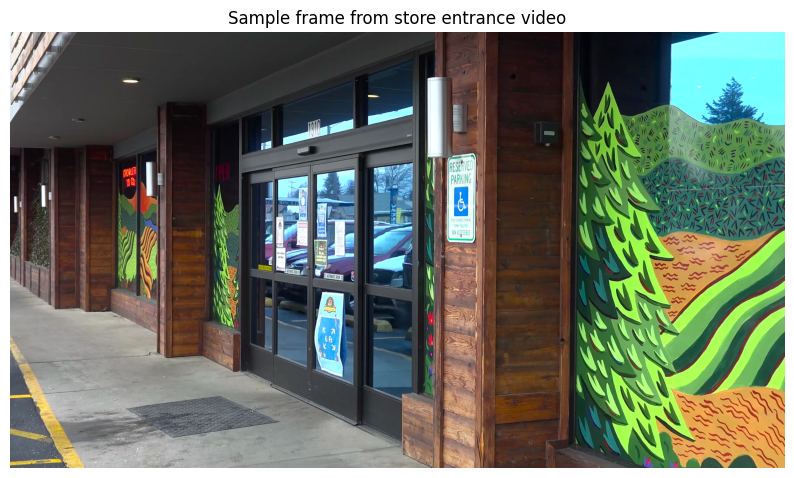

In [4]:
# Video download helper
import urllib.request

def download_video_if_needed(url, local_path):
    """Download video from URL if not already present locally."""
    if not os.path.exists(local_path):
        print(f"Downloading video from {url}...")
        os.makedirs(os.path.dirname(local_path), exist_ok=True)
        urllib.request.urlretrieve(url, local_path)
        print("Download complete.")
    else:
        print(f"Using existing local video at {local_path}")

# Store entrance video
video_url = "https://raw.githubusercontent.com/ezponda/ai-application-course-materials/main/data/store_entrance_people_going_in.mp4"
video_path = "../data/store_entrance_people_going_in.mp4"

# Download if needed
download_video_if_needed(video_url, video_path)

# Extract one frame for demonstration
cap = cv2.VideoCapture(video_path)
success, frame = cap.read()
cap.release()

if success:
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 6))
    plt.imshow(frame_rgb)
    plt.title("Sample frame from store entrance video")
    plt.axis("off")
    plt.show()
else:
    print("Failed to read video. Check the path or network connection.")

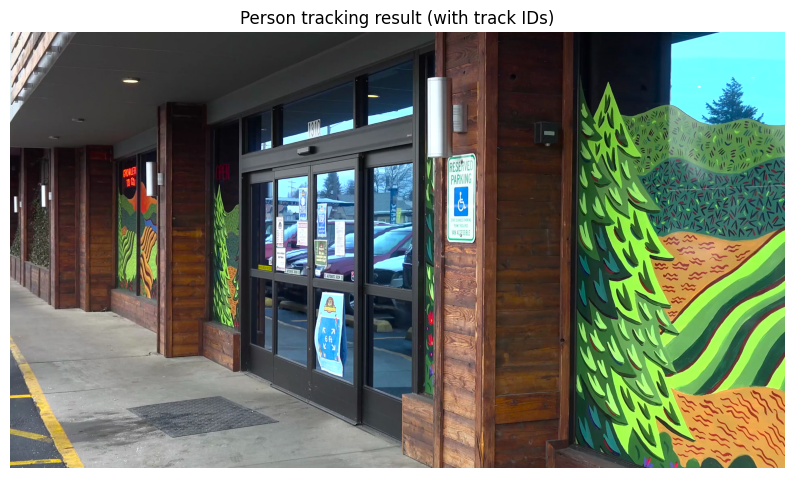

In [5]:
# Run tracking on the single frame (person class only)
results = model.track(frame, persist=True, verbose=False, classes=[0])
result = results[0]

# Display annotated frame
annotated = result.plot()
annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(annotated_rgb)
plt.title("Person tracking result (with track IDs)")
plt.axis("off")
plt.show()

In [6]:
# Inspect the tracking results
print("Tracking results structure:")
print(f"  Classes detected: {result.boxes.cls.cpu().numpy()}")
print(f"  Track IDs: {result.boxes.id.cpu().numpy() if result.boxes.id is not None else 'None'}")

# List detections with their track IDs
if result.boxes.id is not None:
    print("\nDetected people:")
    for i, (cls_id, track_id) in enumerate(zip(result.boxes.cls, result.boxes.id)):
        cls_name = result.names[int(cls_id)]
        print(f"  {i+1}. {cls_name} (Track ID: {int(track_id)})")
else:
    print("\nNo people detected in this frame.")

Tracking results structure:
  Classes detected: []
  Track IDs: None

No people detected in this frame.


## Track IDs and Common Challenges

### What are Track IDs?

Each detected object receives a unique **track ID** that persists across frames. This ID allows us to:

- Count unique objects (not just total detections)
- Measure how long an object stays in view
- Analyze movement patterns and trajectories

### Accessing Track IDs

```python
result.boxes.id  # Tensor of track IDs (one per detection)
result.boxes.cls  # Class indices
result.boxes.xyxy  # Bounding box coordinates
```

### Common Issues

- **ID switches**: When two objects cross paths, the tracker may swap their IDs
- **Lost tracks**: If an object disappears for too long, it may get a new ID when it reappears
- **Fragmented tracks**: Same object might have multiple IDs if detection is intermittent

These issues are inherent to tracking algorithms and can be mitigated by tuning parameters or using more sophisticated trackers.

## Store Entrance Video Demo

Let's run tracking on the entire store entrance video. The loop processes each frame, maintains track history, and displays the results with person detections only.

In [7]:
# Full video tracking loop (people only)
cap = cv2.VideoCapture(video_path)

print("Running video tracking... Press 'q' to stop early.")

while cap.isOpened():
    success, frame = cap.read()
    if not success:
        break
    
    # Run tracking with persistence (person class only)
    results = model.track(frame, persist=True, verbose=False, classes=[0])
    result = results[0]
    
    # Visualize results
    annotated = result.plot()
    show_frame(annotated)
    
    # Exit on 'q' key
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()
print("Video tracking completed.")

Running video tracking... Press 'q' to stop early.


Video tracking completed.


### Optional: Webcam Tracking

If you have a webcam, you can try real-time tracking. This works in local environments but not in hosted notebooks like Colab.

In [8]:
# Optional: Webcam tracking (uncomment to use)
# Requires local environment with webcam access

# cap = cv2.VideoCapture(0)  # 0 = default webcam
# print("Webcam tracking... Press 'q' to stop.")
#
# while cap.isOpened():
#     ret, frame = cap.read()
#     if not ret:
#         break
#     
#     results = model.track(frame, persist=True, verbose=False)
#     annotated = results[0].plot()
#     
#     cv2.imshow("Webcam Tracking", annotated)
#     if cv2.waitKey(1) & 0xFF == ord('q'):
#         break
#
# cap.release()
# cv2.destroyAllWindows()

print("Webcam code is commented out. Uncomment to try real-time tracking.")

Webcam code is commented out. Uncomment to try real-time tracking.


## Counting Customers with Entry/Exit Zones

A common use case for tracking in retail is counting customers who enter and leave the store. We define a **Region of Interest (ROI)** as an entrance zone and track whether people cross it going in or out.

### Why Use an ROI for Store Entrances?

- **Count visitors** entering and leaving your store
- **Calculate footfall metrics** (visitors per hour, daily traffic)
- **Monitor real-time occupancy** by tracking net in/out counts
- **Identify peak hours** for staffing optimization
- **Measure conversion** when combined with Point-of-Sale data

### Simple vs Advanced Counting

For this demonstration, we'll use a simple ROI-based approach that counts unique people passing through an entrance zone. More advanced systems might:

- Use line crossing detection (virtual tripwire)
- Track direction of movement to distinguish in vs out
- Handle multiple entrance points
- Account for people lingering near the entrance

In [9]:
class StoreEntranceCounter:
    """
    Count unique people passing through a store entrance zone.
    """
    
    def __init__(self, roi):
        """
        Args:
            roi: Tuple (x1, y1, x2, y2) defining the entrance zone rectangle
        """
        self.roi = roi
        self.unique_person_ids = set()  # Set of unique track IDs
    
    def is_in_roi(self, box):
        """Check if box center is within the entrance zone."""
        x_center = (box[0] + box[2]) / 2
        y_center = (box[1] + box[3]) / 2
        return (self.roi[0] < x_center < self.roi[2] and 
                self.roi[1] < y_center < self.roi[3])
    
    def update(self, result):
        """Update counts based on tracking results."""
        if result.boxes.id is None:
            return
        
        for i in range(len(result.boxes)):
            box = result.boxes.xyxy[i].cpu().numpy()
            track_id = int(result.boxes.id[i])
            cls_name = result.names[int(result.boxes.cls[i])]
            
            # Only count persons in the entrance zone
            if cls_name == 'person' and self.is_in_roi(box):
                self.unique_person_ids.add(track_id)
    
    def get_count(self):
        """Return count of unique people who passed through entrance."""
        return len(self.unique_person_ids)
    
    def reset(self):
        """Reset the counter."""
        self.unique_person_ids.clear()

In [10]:
# Define entrance zone ROI
# Adjust these coordinates based on your video dimensions
entrance_roi = (200, 100, 600, 400)  # (x1, y1, x2, y2)

counter = StoreEntranceCounter(entrance_roi)

# Run tracking with counting
cap = cv2.VideoCapture(video_path)
print(f"Counting people passing through entrance zone: {entrance_roi}")
print("Running... Press 'q' to stop early.")

while cap.isOpened():
    success, frame = cap.read()
    if not success:
        break
    
    # Run tracking (person class only)
    results = model.track(frame, persist=True, verbose=False, classes=[0])
    result = results[0]
    
    # Update counter
    counter.update(result)
    
    # Display with ROI
    annotated = result.plot()
    
    # Add count overlay
    count = counter.get_count()
    text = f"Unique Visitors: {count}"
    cv2.putText(annotated, text, (10, 30), 
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 0), 2)
    
    show_frame(annotated, entrance_roi)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

print(f"\nFinal count: {counter.get_count()} unique visitors passed through the entrance zone")

Counting people passing through entrance zone: (200, 100, 600, 400)
Running... Press 'q' to stop early.



Final count: 0 unique visitors passed through the entrance zone


### Exercise 1: Count All Unique Visitors

Count total unique people (by track ID) in the entire video.

**Key API:**
- `result.boxes.id` - track IDs (check for None)
- `result.boxes.cls` - class IDs
- Use a `set()` to collect unique IDs

In [11]:
# Exercise 1: Count all unique visitors in the video

cap = cv2.VideoCapture(video_path)
unique_visitor_ids = set()

print("Counting all unique visitors... Press 'q' to stop early.")

while cap.isOpened():
    success, frame = cap.read()
    if not success:
        break
    
    results = model.track(frame, persist=True, verbose=False, classes=[0])
    result = results[0]
    
    # TODO: Loop over detections and add person track IDs to unique_visitor_ids
    # Hint: Check if result.boxes.id is not None before accessing it
    # Hint: Use result.boxes.id to get track IDs
    # Hint: Use int(track_id) to convert to Python int before adding to set
    
    pass  # Your code here
    
    annotated = result.plot()
    show_frame(annotated)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

print(f"\nTotal unique visitors in video: {len(unique_visitor_ids)}")

Counting all unique visitors... Press 'q' to stop early.



Total unique visitors in video: 0


### Exercise 2: Multi-Zone Footfall Analysis

Count people in two separate entrance zones.

**Key API:**
- Define two ROIs: `(x1, y1, x2, y2)`
- Create `StoreEntranceCounter(roi)` for each zone
- Call `counter.update(result)` each frame

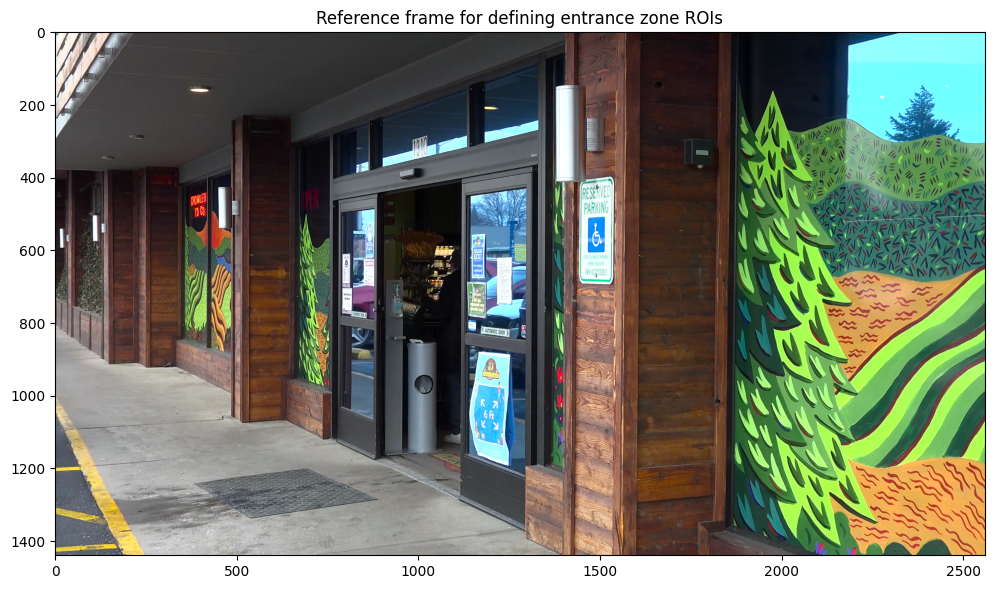

Frame size: 2560 x 1440


In [12]:
# First, visualize a frame to help define entrance zones
cap = cv2.VideoCapture(video_path)
last_frame = None
while cap.isOpened():
    success, frame = cap.read()
    if not success:
        break
    last_frame = frame
cap.release()

if last_frame is not None:
    plt.figure(figsize=(12, 7))
    plt.imshow(cv2.cvtColor(last_frame, cv2.COLOR_BGR2RGB))
    plt.title("Reference frame for defining entrance zone ROIs")
    plt.axis("on")  # Keep axis to see coordinates
    plt.show()
    print(f"Frame size: {last_frame.shape[1]} x {last_frame.shape[0]}")

In [13]:
# Exercise 2: Multi-zone footfall counting

# TODO: Define ROIs for two entrance zones based on the reference frame above
# Hint: ROI format is (x1, y1, x2, y2) where (x1, y1) is top-left corner
# Example: zone_1_roi = (100, 100, 400, 400)
zone_1_roi = None  # Replace with actual coordinates
zone_2_roi = None  # Replace with actual coordinates

# TODO: Create two StoreEntranceCounter instances, one for each zone
# Hint: StoreEntranceCounter(zone_1_roi)
zone_1_counter = None  # Your counter here
zone_2_counter = None  # Your counter here

# TODO: Run tracking loop and update both counters
# Hint: Call counter.update(result) for each counter
# Hint: Draw both ROIs on the annotated frame using cv2.rectangle
# Hint: Display counts for both zones in the overlay text

pass  # Your tracking loop here

# TODO: Print final counts
# Hint: Use counter.get_count() to get visitor count
# Calculate and print: zone 1 visitors, zone 2 visitors, total, difference

pass  # Your print statements here

## Recap

### Key Takeaways

- **People tracking** extends detection by maintaining consistent IDs across frames
- **Tracking-by-detection** runs a detector on each frame and associates detections over time
- **Track IDs** (`result.boxes.id`) uniquely identify each person throughout a video
- **`model.track(..., persist=True, classes=[0])`** tracks people specifically with maintained history
- **Tracking algorithms** (BoT-SORT, ByteTrack) differ in handling occlusions and ID associations
- **Region of Interest (ROI)** allows focused counting in entrance zones
- **Unique visitor counting** uses track IDs to avoid double-counting the same person
- **Common challenges**: Occlusion, ID switches, missed detections, crowding, people entering/leaving

### Retail Applications

- **Footfall metrics**: Simple ROI-based counting provides visitor traffic data
- **Conversion analysis**: Combine footfall counts with sales data to estimate conversion rates
- **Peak hour identification**: Track visitor patterns over time to optimize staffing
- **Campaign evaluation**: Measure impact of promotions on store visits
- **Occupancy management**: Real-time in/out counting helps manage store capacity